In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ase.io import read
from pathlib import Path

In [21]:
def main(output_dir, rho: int) -> None:
    """
    Lê todos os arquivos scf.*.out, extrai a energia por átomo em eV.
    
    """
    NUM_ATOMOS = 4
  
    files = list( Path(output_dir).glob(f'scf*.{rho}.out') )
    energies = [read(f, format='espresso-out').get_total_energy() / NUM_ATOMOS for f in files]

    data: list[list[str, float]] = [[f.name, e] for f,e in zip(files, energies)]
    # Ordem descrescente de energia.
    data.sort(key=lambda x: x[1], reverse=True)
    return data

In [22]:
rho8  =  main(output_dir='./outputs', rho=8)
rho10 =  main(output_dir='./outputs', rho=10)
rho12 =  main(output_dir='./outputs', rho=12)

df8 = pd.DataFrame(rho8, columns=['File', 'E/atom'])
df10 = pd.DataFrame(rho10, columns=['File', 'E/atom'])
df12 = pd.DataFrame(rho12, columns=['File', 'E/atom'])


In [23]:
get_deltaE_consec = lambda x: np.abs(np.r_[0, np.diff(x)])
get_deltaEref = lambda x: np.abs(x -np.min(x))

for df in [df8, df10, df12]:    
    df['dE_ref_meV'] = get_deltaEref(df['E/atom']) * 1_000
    df['dE_consec_meV'] = get_deltaE_consec(df['E/atom']) * 1_000

In [24]:
df8.head()

,File,E/atom,dE_ref_meV,dE_consec_meV
0,scf_ecutwfc.20.8.out,-1204.090669,26018.730714,0.000000
1,scf_ecutwfc.30.8.out,-1228.730884,1378.516019,24640.214695
2,scf_ecutwfc.40.8.out,-1230.035343,74.057482,1304.458537
3,scf_ecutwfc.50.8.out,-1230.068955,40.445164,33.612318
4,scf_ecutwfc.60.8.out,-1230.094820,14.580404,25.864761


Visualizando em Painel.

In [25]:
pd.concat([df8.T, df10.T, df12.T], axis=0)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
File,scf_ecutwfc.20.8.out,scf_ecutwfc.30.8.out,scf_ecutwfc.40.8.out,scf_ecutwfc.50.8.out,scf_ecutwfc.60.8.out,scf_ecutwfc.70.8.out,scf_ecutwfc.80.8.out,scf_ecutwfc.90.8.out,scf_ecutwfc.100.8.out,scf_ecutwfc.110.8.out,scf_ecutwfc.120.8.out,scf_ecutwfc.130.8.out,scf_ecutwfc.140.8.out,scf_ecutwfc.150.8.out
E/atom,-1204.090669,-1228.730884,-1230.035343,-1230.068955,-1230.09482,-1230.102385,-1230.105211,-1230.107359,-1230.108113,-1230.108406,-1230.108841,-1230.109242,-1230.109381,-1230.1094
dE_ref_meV,26018.730714,1378.516019,74.057482,40.445164,14.580404,7.014653,4.188852,2.04082,1.287235,0.99393,0.559364,0.157588,0.01864,0.0
dE_consec_meV,0.0,24640.214695,1304.458537,33.612318,25.864761,7.565751,2.8258,2.148033,0.753585,0.293305,0.434566,0.401776,0.138948,0.01864
File,scf_ecutwfc.20.10.out,scf_ecutwfc.30.10.out,scf_ecutwfc.40.10.out,scf_ecutwfc.50.10.out,scf_ecutwfc.60.10.out,scf_ecutwfc.70.10.out,scf_ecutwfc.80.10.out,scf_ecutwfc.90.10.out,scf_ecutwfc.100.10.out,scf_ecutwfc.110.10.out,scf_ecutwfc.120.10.out,scf_ecutwfc.130.10.out,scf_ecutwfc.140.10.out,scf_ecutwfc.150.10.out
E/atom,-1204.088481,-1228.73073,-1230.035337,-1230.068957,-1230.094823,-1230.102381,-1230.105206,-1230.107354,-1230.108114,-1230.108398,-1230.108843,-1230.109235,-1230.109381,-1230.109397
dE_ref_meV,26020.91606,1378.667451,74.059795,40.439518,14.573941,7.015639,4.191165,2.042657,1.283119,0.999202,0.553582,0.162112,0.016293,0.0
dE_consec_meV,0.0,24642.248609,1304.607656,33.620277,25.865577,7.558302,2.824474,2.148509,0.759538,0.283917,0.44562,0.39147,0.145819,0.016293
File,scf_ecutwfc.20.12.out,scf_ecutwfc.30.12.out,scf_ecutwfc.40.12.out,scf_ecutwfc.50.12.out,scf_ecutwfc.60.12.out,scf_ecutwfc.70.12.out,scf_ecutwfc.80.12.out,scf_ecutwfc.90.12.out,scf_ecutwfc.100.12.out,scf_ecutwfc.110.12.out,scf_ecutwfc.120.12.out,scf_ecutwfc.130.12.out,scf_ecutwfc.140.12.out,scf_ecutwfc.150.12.out
E/atom,-1204.088531,-1228.730724,-1230.035345,-1230.068965,-1230.094823,-1230.102378,-1230.105202,-1230.107352,-1230.108112,-1230.108395,-1230.108841,-1230.109233,-1230.10938,-1230.109396


Para um pseudopotencial __ultrasoft__ o corte considerando um $\Delta E$ < 2 meV está bem __alto__!

Escolhido para Threshold = 2 meV
<div align="center">
    
    - ecutwfc = 100 Ry
    - ecutrho = 800 Ry

</div>    

Escolhido para Threshold = 5 meV
<div align="center">
    
    - ecutwfc = 80 Ry
    - ecutrho = 640 Ry

</div>    

Plotando 

In [26]:
df8.head()

,File,E/atom,dE_ref_meV,dE_consec_meV
0,scf_ecutwfc.20.8.out,-1204.090669,26018.730714,0.000000
1,scf_ecutwfc.30.8.out,-1228.730884,1378.516019,24640.214695
2,scf_ecutwfc.40.8.out,-1230.035343,74.057482,1304.458537
3,scf_ecutwfc.50.8.out,-1230.068955,40.445164,33.612318
4,scf_ecutwfc.60.8.out,-1230.094820,14.580404,25.864761


In [27]:
def plot_convergence(data: pd.DataFrame, pseudopot_title: str, save: bool = False):
    """
    Args:
        data: DataFrame with columns: File	E/atom	dE_ref_meV	dE_consec_meV
        pseudopot_title: string containing info about selected pseudopotential.
    """

    ecut = np.array(list(range(20, 160, 10)))
    THR = 2.0  # meV

    E_per_atom     = df8['E/atom'].to_numpy()
    dE_ref_meV     = df8['dE_ref_meV'].to_numpy()
    dE_consec_meV  = df8['dE_consec_meV'].to_numpy()

    fig, (axE, axdE) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(6, 6),
        dpi=300,
        gridspec_kw={'hspace': 0.05}
    )

    # === Painel (a): energia por átomo vs cutoff ===
    axE.set_title(pseudopot_title)
    axE.set_ylabel(r'$E$ (eV/atom)')
    axE.plot(ecut, E_per_atom, marker='s', ls='-', color='black', label=r'$E_i$')
    axE.scatter(ecut[-1], E_per_atom[-1], marker='v', color='black')
    axE.legend()

    # === Painel (b): diferenças em meV/átomo ===

    # Módulo das diferenças
    dE_ref_abs    = np.abs(dE_ref_meV)
    dE_consec_abs = np.abs(dE_consec_meV)

    # Limite superior do eixo y na região de interesse
    YMAX = 10.0  # meV (ajuste se quiser)

    # Versões "clipadas" para plotar
    dE_ref_plot    = np.clip(dE_ref_abs,    0, YMAX)
    dE_consec_plot = np.clip(dE_consec_abs, 0, YMAX)

    axdE.plot(ecut, dE_ref_plot, marker='s', ls='-', label=r'$|E_i - E_{\mathrm{ref}}|$')
    axdE.plot(ecut, dE_consec_plot, marker='o', ls='--', label=r'$|E_i - E_{i-1}|$')

    # Marcar pontos que saturaram (valores reais > YMAX)
    mask_ref_sat    = dE_ref_abs    > YMAX
    mask_consec_sat = dE_consec_abs > YMAX

    axdE.scatter(ecut[mask_ref_sat],
                np.full(mask_ref_sat.sum(), YMAX),
                marker='v', s=40, color='C0')
    axdE.scatter(ecut[mask_consec_sat],
                np.full(mask_consec_sat.sum(), YMAX),
                marker='v', s=40, color='C1')


    # Faixa de tolerância 0–2 meV/átomo
    axdE.axhspan(0.0, THR, alpha=0.15, color='red')

    axdE.set_ylabel(r'$\Delta E$ (meV/atom)')
    axdE.set_xlabel(r'Kinetic energy cutoff (Ry)', labelpad=10)
    axdE.set_ylim(0, YMAX)

    axdE.legend(fontsize=8, loc='upper right')
    if save:
        formats = ["pdf", "png"]
        nome_figura = input("Digite o nome da figura a ser salva:\nEx: minhafigura.{pdf,png}\n")
        formato = nome_figura[-3:]
        if formato not in formats: 
            raise ValueError("Formato não aceito.\n Aceitos: '.pdf', '.png'")
        fig.savefig(nome_figura,format=formato, bbox_inches='tight')
    
    plt.show()


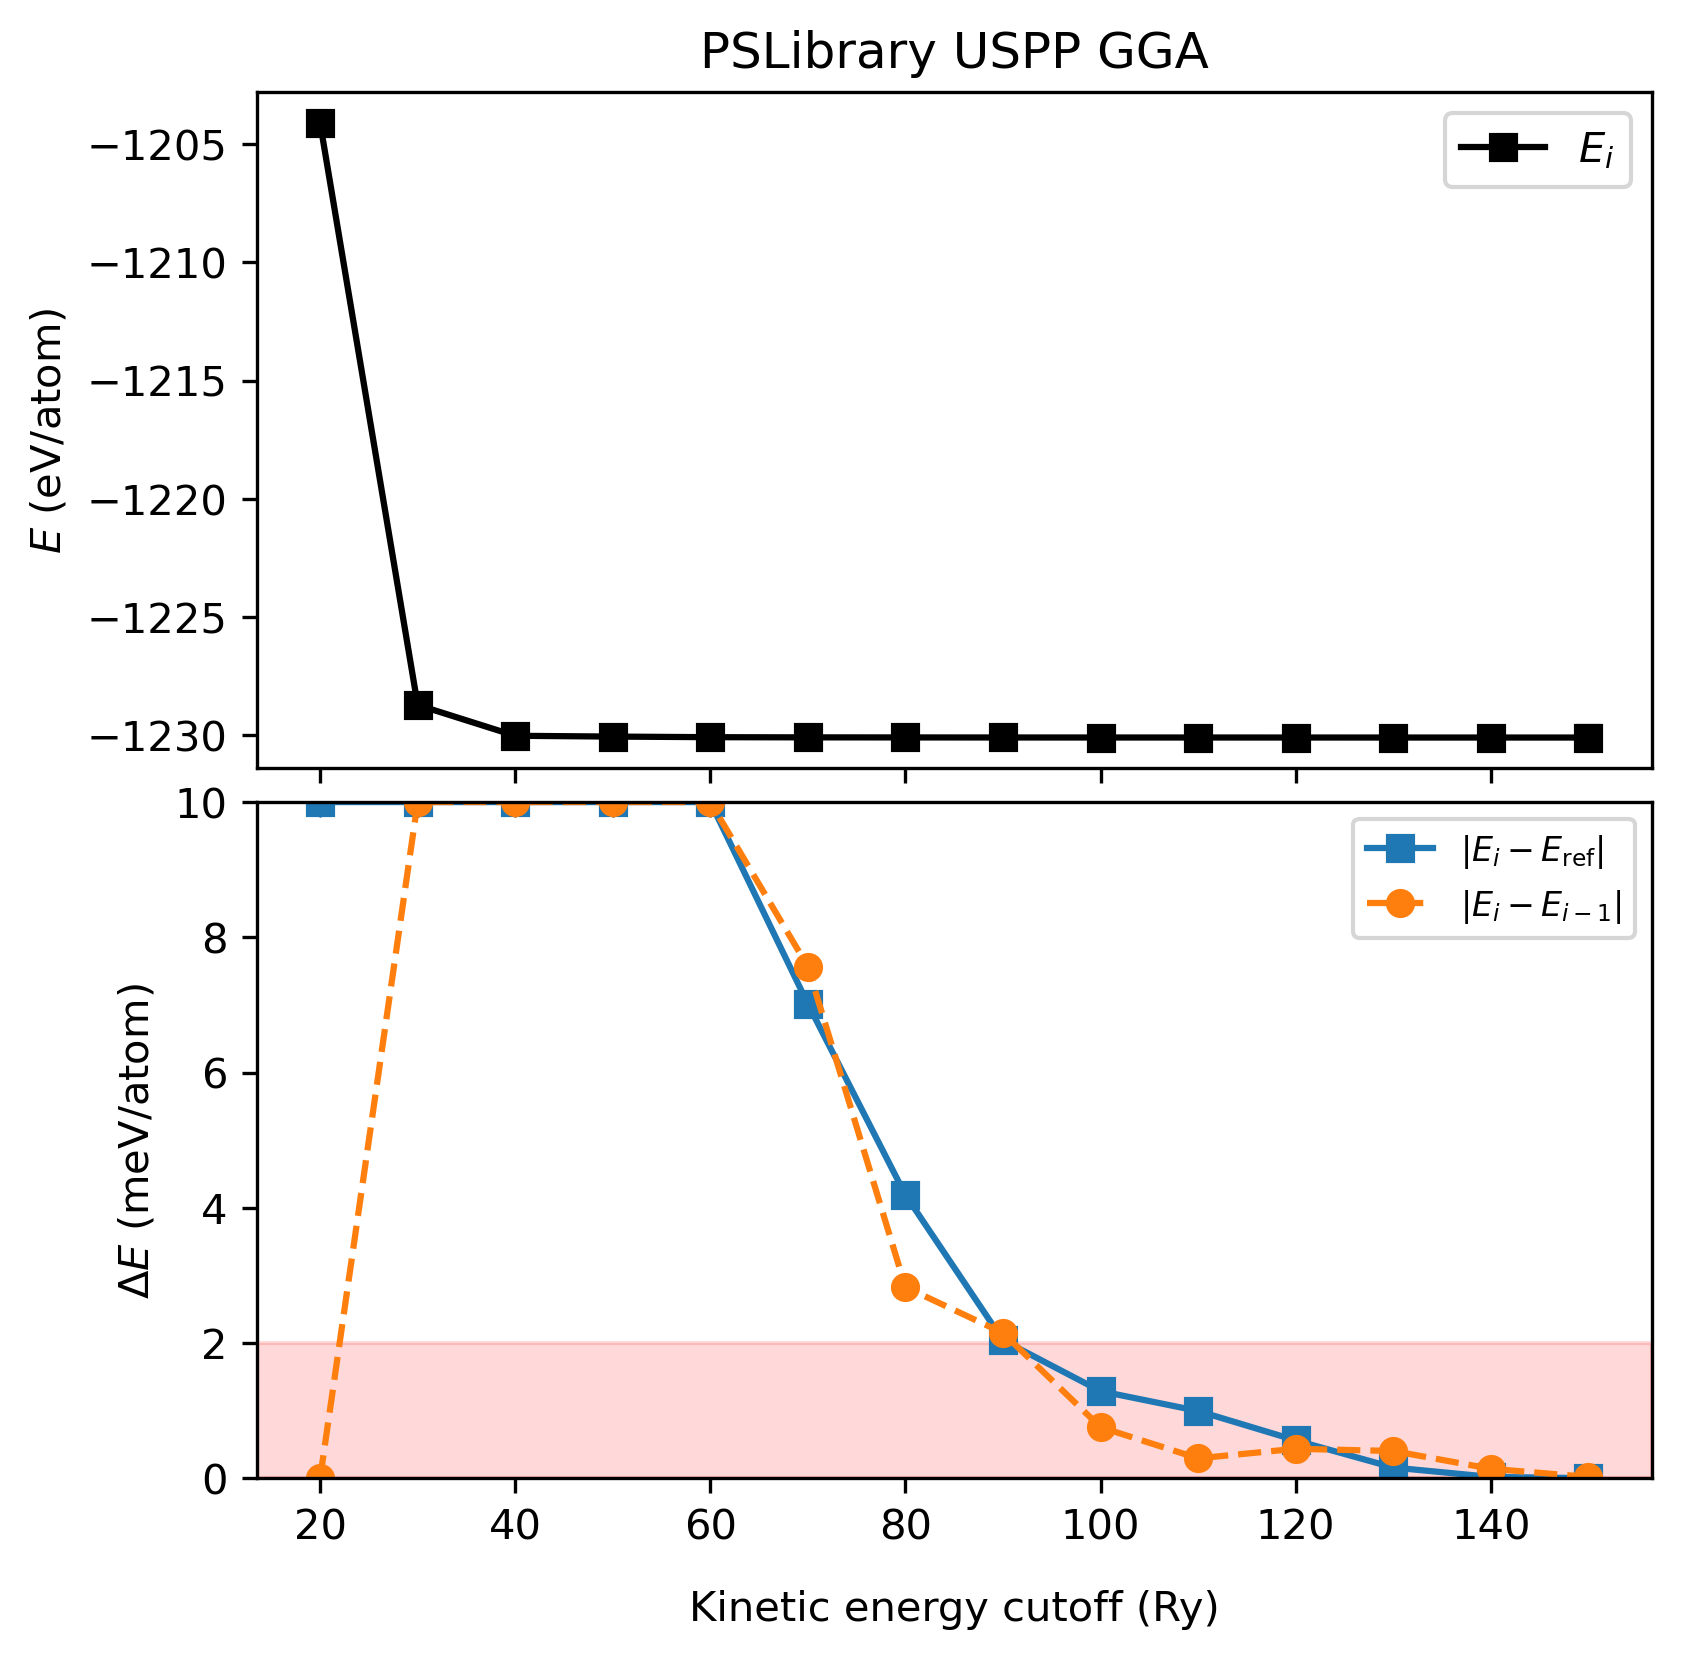

In [28]:
plot_convergence(data=df8, pseudopot_title="PSLibrary USPP GGA", save=True)